# Tarea 1: Adquisición y preparación de datos: API o Web Scraping



API del Banco Mundial (World Bank)

En base a la información general de la API del Banco Mundial disponible en este link:

https://datahelpdesk.worldbank.org/knowledgebase/articles/889392-about-the-indicators-api-documentation

Y de las instrucciones para consultar la API:

https://datahelpdesk.worldbank.org/knowledgebase/articles/898581

He elegido trabajar con los indicadores  Mortality rate, under-5 (per 1,000 live births) y Adolescent fertility rate (births per 1,000 women ages 15-19) incluidos en el siguiente link:

https://datatopics.worldbank.org/world-development-indicators/themes/people.html

Ello, considerando que son de los que cuentan con mayor cobertura en las diferentes regiones.

Primero importo librerías a emplear y hago el llamado a la API para extraer los datos para el año 2023.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
# Configuro las url con los codigos de los indicadores y el año
url_mortalidad = "http://api.worldbank.org/v2/country/all/indicator/SH.DYN.MORT?format=json&date=2023&per_page=300"
url_embarazo = "http://api.worldbank.org/v2/country/all/indicator/SP.ADO.TFRT?format=json&date=2023&per_page=300"

#Capturo la información en formato JSON
#La primera entrada [0] corresponde a metadatos
rpta_mortalidad = requests.get(url_mortalidad).json()[1]
rpta_embarazo = requests.get(url_embarazo).json()[1]



[{'indicator': {'id': 'SP.ADO.TFRT',
   'value': 'Adolescent fertility rate (births per 1,000 women ages 15-19)'},
  'country': {'id': 'ZH', 'value': 'Africa Eastern and Southern'},
  'countryiso3code': 'AFE',
  'date': '2023',
  'value': 92.3064528575241,
  'unit': '',
  'obs_status': '',
  'decimal': 0},
 {'indicator': {'id': 'SP.ADO.TFRT',
   'value': 'Adolescent fertility rate (births per 1,000 women ages 15-19)'},
  'country': {'id': 'ZI', 'value': 'Africa Western and Central'},
  'countryiso3code': 'AFW',
  'date': '2023',
  'value': 94.9696321003397,
  'unit': '',
  'obs_status': '',
  'decimal': 0},
 {'indicator': {'id': 'SP.ADO.TFRT',
   'value': 'Adolescent fertility rate (births per 1,000 women ages 15-19)'},
  'country': {'id': '1A', 'value': 'Arab World'},
  'countryiso3code': 'ARB',
  'date': '2023',
  'value': 44.7865562834154,
  'unit': '',
  'obs_status': '',
  'decimal': 0},
 {'indicator': {'id': 'SP.ADO.TFRT',
   'value': 'Adolescent fertility rate (births per 1,000 

Ahora traspaso la información a DataSets

In [42]:
#Normalizo y convierto en DataSet
df_mortalidad = pd.json_normalize(rpta_mortalidad)
df_embarazo = pd.json_normalize(rpta_embarazo)


Analizo cada DataSet para seleccionar columnas de interés.

In [43]:
df_mortalidad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  266 non-null    object 
 1   date             266 non-null    object 
 2   value            244 non-null    float64
 3   unit             266 non-null    object 
 4   obs_status       266 non-null    object 
 5   decimal          266 non-null    int64  
 6   indicator.id     266 non-null    object 
 7   indicator.value  266 non-null    object 
 8   country.id       266 non-null    object 
 9   country.value    266 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 20.9+ KB


Eliminamos indicador (id y value) porque corresponde al filtro empleado, así como el año (date)

In [44]:
df_mortalidad = df_mortalidad.drop(columns=['indicator.id', 'indicator.value','date'])
df_mortalidad.head()

,countryiso3code,value,unit,obs_status,decimal,country.id,country.value
0,AFE,59.375649,,,0,ZH,Africa Eastern and Southern
1,AFW,93.138463,,,0,ZI,Africa Western and Central
2,ARB,35.065839,,,0,1A,Arab World
3,CSS,18.673428,,,0,S3,Caribbean small states
4,CEB,4.752437,,,0,B8,Central Europe and the Baltics


Eliminamos unit, obs_status, decimal, country.id (nos quedamos solo con el codigo 3 ISO)

In [45]:
df_mortalidad=df_mortalidad.drop(columns=['unit','obs_status','decimal','country.id'])
df_mortalidad.head()

,countryiso3code,value,country.value
0,AFE,59.375649,Africa Eastern and Southern
1,AFW,93.138463,Africa Western and Central
2,ARB,35.065839,Arab World
3,CSS,18.673428,Caribbean small states
4,CEB,4.752437,Central Europe and the Baltics


Convertimos las columnas countryiso3code y contry.value a str.

In [46]:
df_mortalidad["countryiso3code"].astype(str)
df_mortalidad["country.value"].astype(str)
df_mortalidad.head()

,countryiso3code,value,country.value
0,AFE,59.375649,Africa Eastern and Southern
1,AFW,93.138463,Africa Western and Central
2,ARB,35.065839,Arab World
3,CSS,18.673428,Caribbean small states
4,CEB,4.752437,Central Europe and the Baltics


Inspeccionemos ahora el DataSet de embarazos adolescentes.

In [22]:
df_embarazo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   countryiso3code  266 non-null    object 
 1   date             266 non-null    object 
 2   value            265 non-null    float64
 3   unit             266 non-null    object 
 4   obs_status       266 non-null    object 
 5   decimal          266 non-null    int64  
 6   indicator.id     266 non-null    object 
 7   indicator.value  266 non-null    object 
 8   country.id       266 non-null    object 
 9   country.value    266 non-null    object 
dtypes: float64(1), int64(1), object(8)
memory usage: 20.9+ KB


Siguiendo la logica del DataSet anterior, nos quedamos con las columnas countryiso3code y value

In [47]:
df_embarazo = df_embarazo[['countryiso3code', 'value']]
df_embarazo["countryiso3code"].astype(str)
df_embarazo.head()

,countryiso3code,value
0,AFE,92.306453
1,AFW,94.969632
2,ARB,44.786556
3,CSS,46.381131
4,CEB,15.935619


Unimos los datos de ambos indicadores para empezar a trabajarlos.

In [48]:
df = pd.merge(df_mortalidad, df_embarazo, on='countryiso3code')
df.rename(columns={'countryiso3code': 'cod_pais','value_x': 'mort_infantil', 'value_y': 'emb_adolescente','country.value': 'pais'}, inplace=True)
df.head(20)

,cod_pais,mort_infantil,pais,emb_adolescente
0,AFE,59.375649,Africa Eastern and Southern,92.306453
1,AFW,93.138463,Africa Western and Central,94.969632
2,ARB,35.065839,Arab World,44.786556
3,CSS,18.673428,Caribbean small states,46.381131
4,CEB,4.752437,Central Europe and the Baltics,15.935619
5,EAR,30.878583,Early-demographic dividend,33.362585
6,EAS,13.700000,East Asia & Pacific,14.565837
7,EAP,14.474959,East Asia & Pacific (excluding high income),15.590081
8,TEA,14.413048,East Asia & Pacific (IDA & IBRD countries),15.778614
9,EMU,3.670106,Euro area,4.535189


Al ver los datos, notamos que no solo estan los paises, sino que también hay informacion consolidada por regiones. Debemos filtrar las filas que corresponden unicamente a paises. Para ello, usamos otra API del Banco Mundial que nos lista los paises.

In [49]:
url_paises = "http://api.worldbank.org/v2/country/all?format=json&per_page=300"
paises = requests.get(url_paises).json()[1]
paises


[{'id': 'ABW',
  'iso2Code': 'AW',
  'name': 'Aruba',
  'region': {'id': 'LCN',
   'iso2code': 'ZJ',
   'value': 'Latin America & Caribbean '},
  'adminregion': {'id': '', 'iso2code': '', 'value': ''},
  'incomeLevel': {'id': 'HIC', 'iso2code': 'XD', 'value': 'High income'},
  'lendingType': {'id': 'LNX', 'iso2code': 'XX', 'value': 'Not classified'},
  'capitalCity': 'Oranjestad',
  'longitude': '-70.0167',
  'latitude': '12.5167'},
 {'id': 'AFE',
  'iso2Code': 'ZH',
  'name': 'Africa Eastern and Southern',
  'region': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'},
  'adminregion': {'id': '', 'iso2code': '', 'value': ''},
  'incomeLevel': {'id': 'NA', 'iso2code': 'NA', 'value': 'Aggregates'},
  'lendingType': {'id': '', 'iso2code': '', 'value': 'Aggregates'},
  'capitalCity': '',
  'longitude': '',
  'latitude': ''},
 {'id': 'AFG',
  'iso2Code': 'AF',
  'name': 'Afghanistan',
  'region': {'id': 'MEA',
   'iso2code': 'ZQ',
   'value': 'Middle East, North Africa, Afghanistan & Pa

El id del pais corresponde al codigo ISO 3. Creamos un diccionario de paises, es decir, todos aquellos que pertenecen a alguna región.

In [50]:
paises_validos = {pais['id']: pais['name'] for pais in paises if pais['region']['id'] != 'NA'}
paises_validos

{'ABW': 'Aruba',
 'AFG': 'Afghanistan',
 'AGO': 'Angola',
 'ALB': 'Albania',
 'AND': 'Andorra',
 'ARE': 'United Arab Emirates',
 'ARG': 'Argentina',
 'ARM': 'Armenia',
 'ASM': 'American Samoa',
 'ATG': 'Antigua and Barbuda',
 'AUS': 'Australia',
 'AUT': 'Austria',
 'AZE': 'Azerbaijan',
 'BDI': 'Burundi',
 'BEL': 'Belgium',
 'BEN': 'Benin',
 'BFA': 'Burkina Faso',
 'BGD': 'Bangladesh',
 'BGR': 'Bulgaria',
 'BHR': 'Bahrain',
 'BHS': 'Bahamas, The',
 'BIH': 'Bosnia and Herzegovina',
 'BLR': 'Belarus',
 'BLZ': 'Belize',
 'BMU': 'Bermuda',
 'BOL': 'Bolivia',
 'BRA': 'Brazil',
 'BRB': 'Barbados',
 'BRN': 'Brunei Darussalam',
 'BTN': 'Bhutan',
 'BWA': 'Botswana',
 'CAF': 'Central African Republic',
 'CAN': 'Canada',
 'CHE': 'Switzerland',
 'CHI': 'Channel Islands',
 'CHL': 'Chile',
 'CHN': 'China',
 'CIV': "Cote d'Ivoire",
 'CMR': 'Cameroon',
 'COD': 'Congo, Dem. Rep.',
 'COG': 'Congo, Rep.',
 'COL': 'Colombia',
 'COM': 'Comoros',
 'CPV': 'Cabo Verde',
 'CRI': 'Costa Rica',
 'CUB': 'Cuba',
 '

Filtramos nuestro DataSet usando el diccionario de paises.

In [51]:
df = df[df['cod_pais'].isin(paises_validos.keys())].copy()
df

,cod_pais,mort_infantil,pais,emb_adolescente
69,AFG,54.9,Afghanistan,64.068
70,ALB,9.4,Albania,12.789
71,DZA,22.0,Algeria,8.698
72,ASM,NaN,American Samoa,34.181
73,AND,2.6,Andorra,3.480
...,...,...,...,...
281,VIR,NaN,Virgin Islands (U.S.),31.777
282,PSE,41.9,West Bank and Gaza,36.043
283,YEM,39.5,"Yemen, Rep.",75.328
284,ZMB,49.1,Zambia,115.907


Eliminamos filas con valores nulos en alguno de los indicadores. Verificamos que no exista valores nulos.

In [54]:
df.dropna(subset=['emb_adolescente', 'mort_infantil'], inplace=True)
df.isna().sum()

,0
cod_pais,0
mort_infantil,0
pais,0
emb_adolescente,0


Comparamos ambos indicadores para verificar si existe alguna correlación entre ellos.

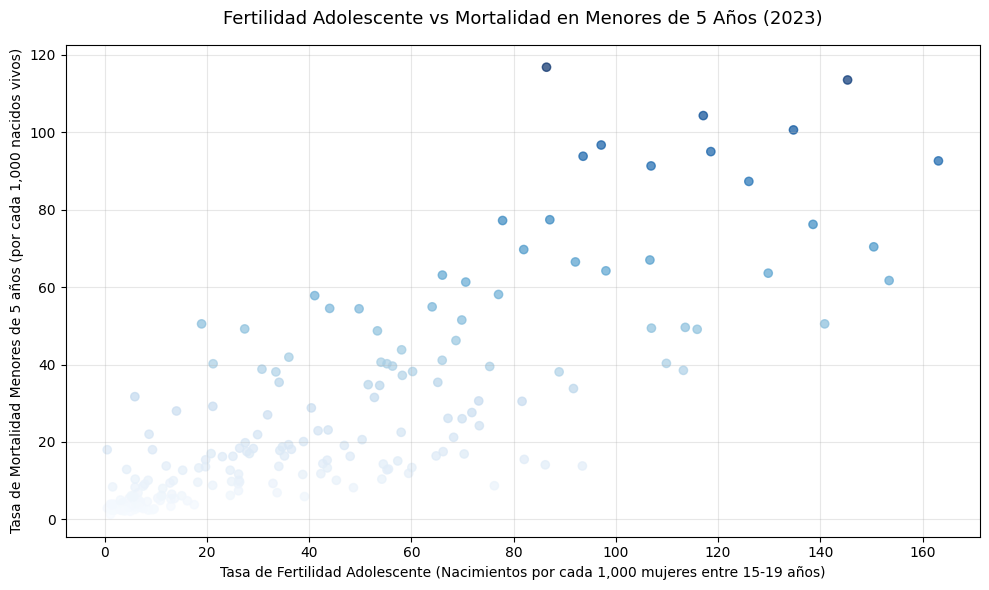

In [56]:
plt.figure(figsize=(10, 6))

plt.scatter(df['emb_adolescente'], df['mort_infantil'],
            alpha=0.7, c=df['mort_infantil'], cmap='Blues')
plt.title('Fertilidad Adolescente vs Mortalidad en Menores de 5 Años (2023)', fontsize=13, pad=15)
plt.xlabel('Tasa de Fertilidad Adolescente (Nacimientos por cada 1,000 mujeres entre 15-19 años)')
plt.ylabel('Tasa de Mortalidad Menores de 5 años (por cada 1,000 nacidos vivos)')

plt.grid(True, alpha=0.3)
plt.tight_layout()

Se observa una correlación positiva entre las tasas de mortalidad infantil (menores de 5) y la de embarazos en adolescentes (entre 15 y 19 años).

 **Reflexión ética sobre permisos, riesgos y
limitaciones.** Si bien las APIs empleadas en la presente Tarea no se encontraban en la lista del enunciado, la información del Banco Mundial se han empleado en otros laboratorios y corresponde a información pública y de uso general, por lo que no implica mayores permisos ni riesgos.